# Figure 1 - Ranking por representacao em cada dataset\n
Notebook reduzido para uma unica figura em formato de paper (3 subplots verticais), usando a metrica Recall@k.

/tmp/ipykernel_9275/4116226119.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Figura salva em: figures/figure1_metodos_recallk.pdf
Figura salva em: figures/figure1_metodos_recallk.png


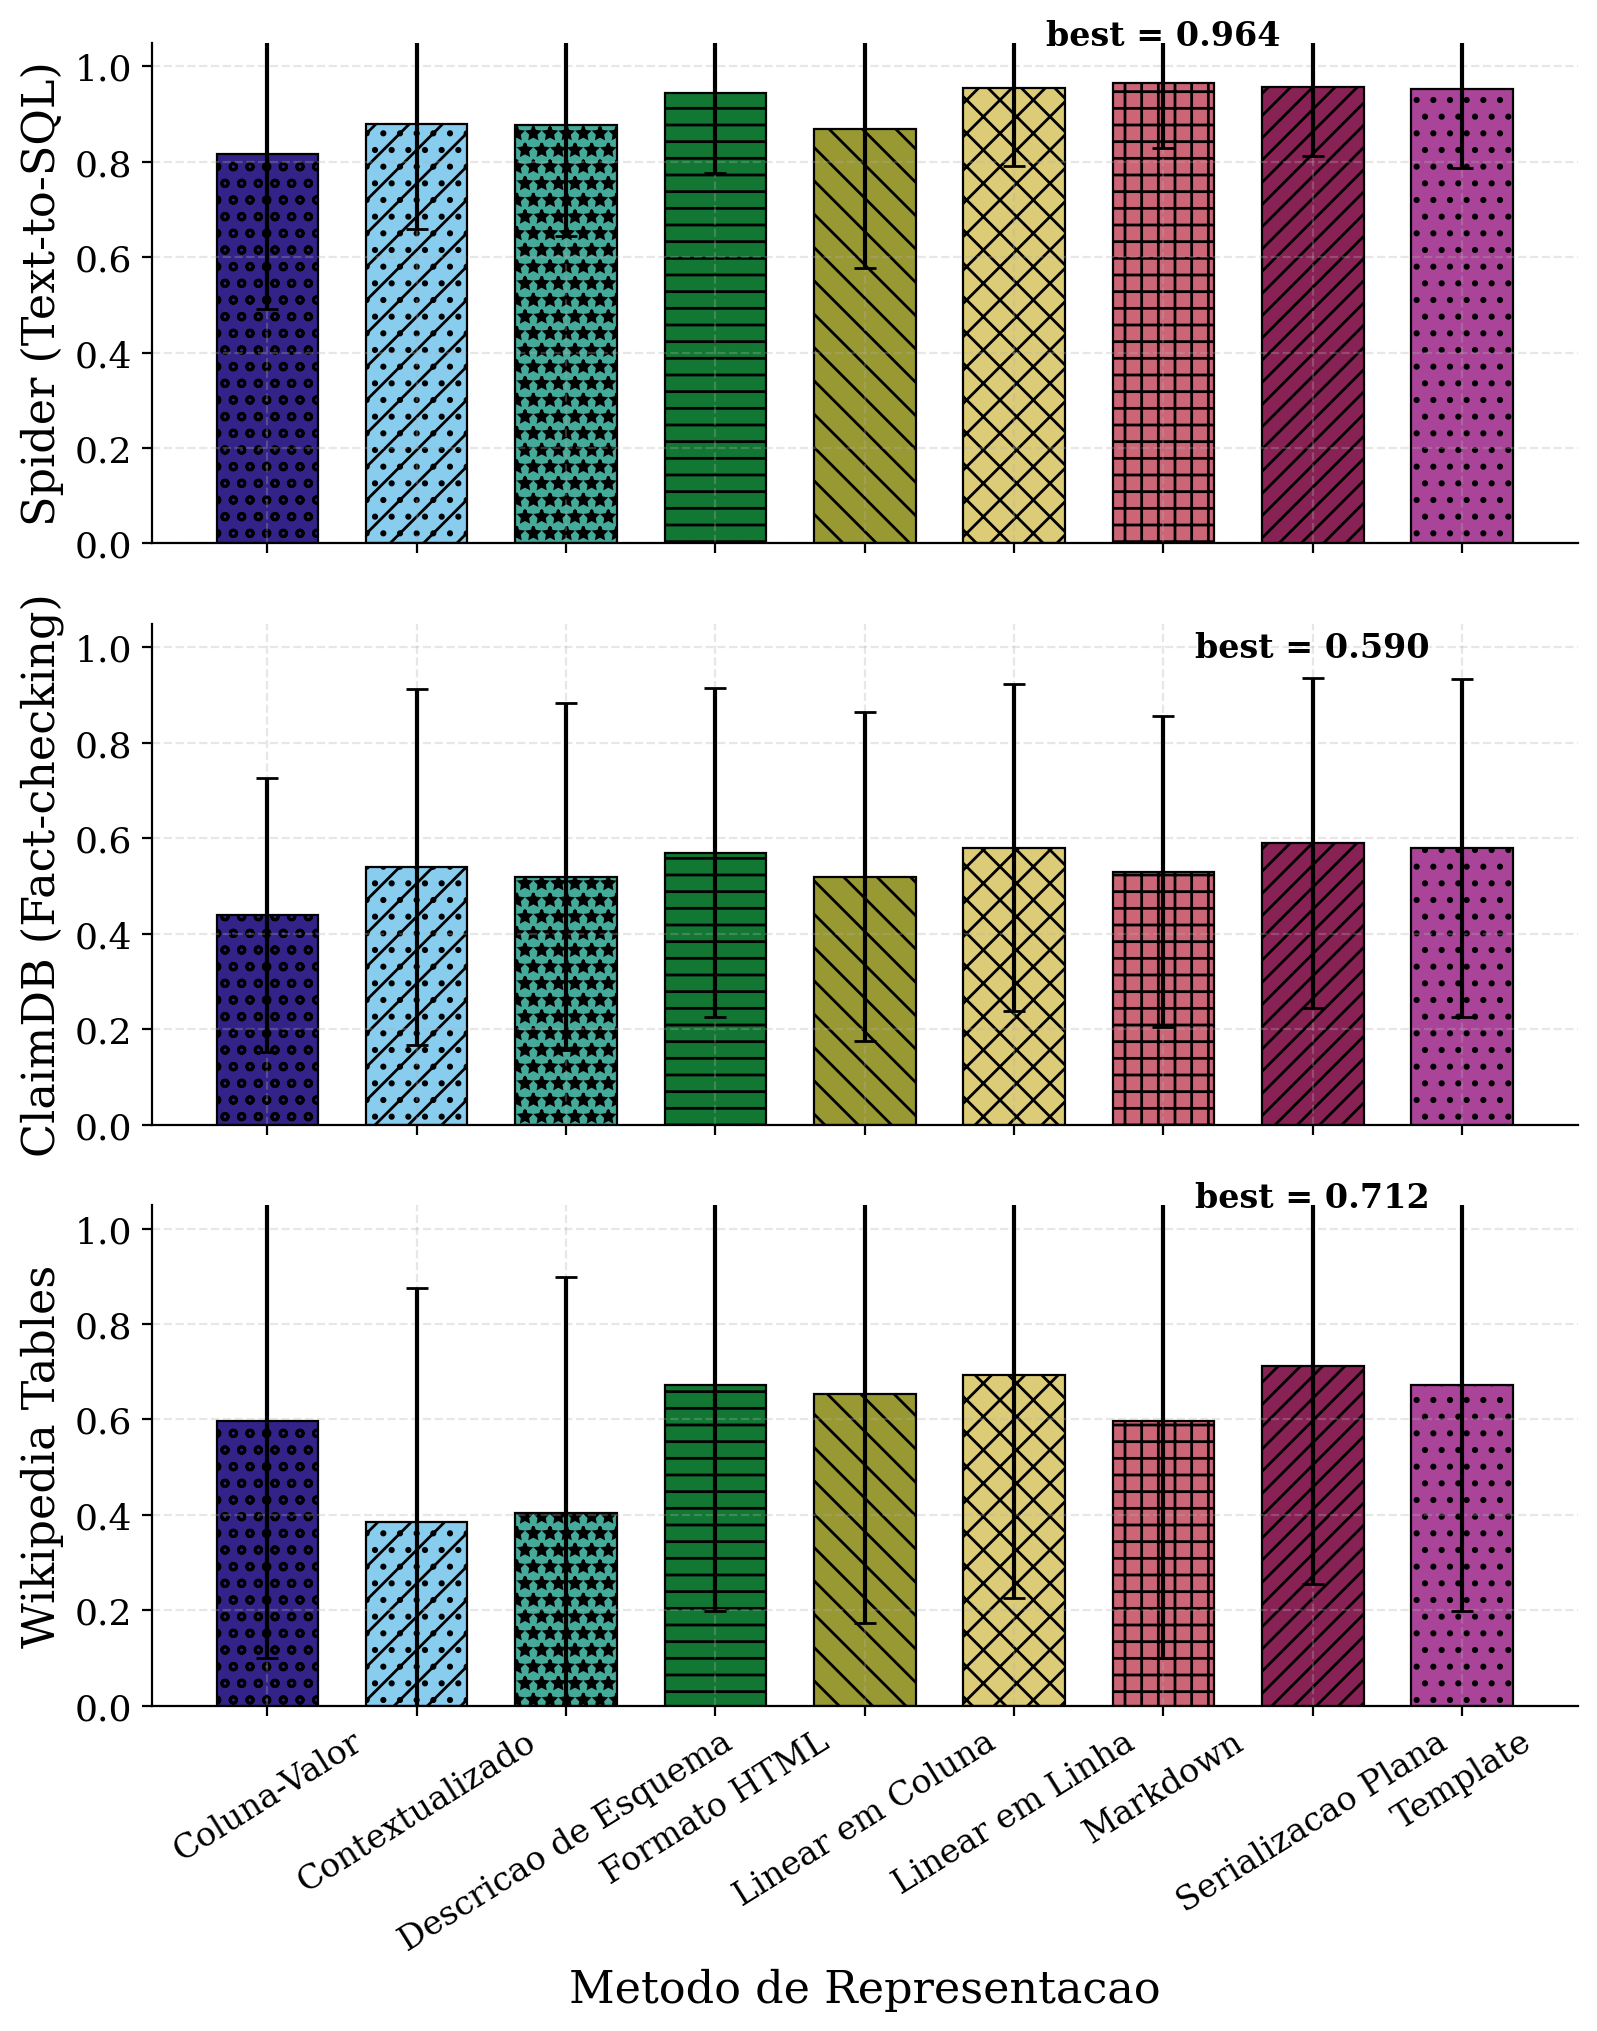

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuracao visual para paper (fonte maior para leitura em figura impressa)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.dpi': 200,
    'axes.grid': True,
    'grid.alpha': 0.30,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Nomes mais descritivos dos metodos
METHOD_NAMES = {
    'serialized_flat': 'Serializacao Plana',
    'linearized_column_wise': 'Linear em Coluna',
    'linearized_row_wise': 'Linear em Linha',
    'template_based': 'Template',
    'markdown': 'Markdown',
    'html_like': 'Formato HTML',
    'column_header_value_triples': 'Coluna-Valor',
    'schema_description': 'Descricao de Esquema',
    'contextualized': 'Contextualizado'
}

# Ordem fixa alfabetica por nome amigavel
METHOD_ORDER = sorted(METHOD_NAMES.keys(), key=lambda k: METHOD_NAMES[k])

DATASET_NAMES = {
    'spider': 'Spider (Text-to-SQL)',
    'claimdb': 'ClaimDB (Fact-checking)',
    'wiki': 'Wikipedia Tables'
}

# Ordem fixa dos datasets (topo -> base)
DATASET_ORDER = ['spider', 'claimdb', 'wiki']

# Paleta linear/sequencial principal
# Opcao atual (linear, perceptualmente uniforme): viridis
palette = sns.color_palette('viridis', n_colors=len(METHOD_ORDER))

# Outras opcoes lineares para testar:
# palette = sns.color_palette('mako', n_colors=len(METHOD_ORDER))
# palette = sns.color_palette('crest', n_colors=len(METHOD_ORDER))
# palette = sns.color_palette('flare', n_colors=len(METHOD_ORDER))

TOL_MUTED_9 = [
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    "#CC6677",  # rose
    "#882255",  # wine
    "#AA4499",  # purple
]
palette = TOL_MUTED_9

METHOD_COLORS = {m: c for m, c in zip(METHOD_ORDER, palette)}

# Hatches para leitura em preto e branco
METHOD_HATCHES = {
    'serialized_flat': '///',
    'linearized_column_wise': '\\\\',
    'linearized_row_wise': 'xx',
    'template_based': '..',
    'markdown': '++',
    'html_like': '--',
    'column_header_value_triples': 'oo',
    'schema_description': '**',
    'contextualized': '//..'
}

datasets = {
    'spider': pd.read_csv('../data/spider/results.csv'),
    'claimdb': pd.read_csv('../data/claimdb/results_claim.csv'),
    'wiki': pd.read_csv('../data/wiki/result_wiki.csv')
}

def extract_recall_at_k(series):
    text = series.astype(str)
    #recall = text.str.extract(r'precision:\s*([0-9]*\.?[0-9]+)', expand=False)
    recall = text.str.extract(r'(?:precision:|precision@\d+:)\s*([0-9]*\.?[0-9]+)', expand=False)
    fallback = text.str.extract(r'([0-9]*\.?[0-9]+)', expand=False)
    return recall.fillna(fallback).astype(float)

aggregated = {}
for key, df in datasets.items():
    temp = df.copy()
    temp['recall_at_k'] = extract_recall_at_k(temp['Evalution'])

    # Media e variabilidade por metodo
    agg = temp.groupby('Representation', as_index=False)['recall_at_k'].agg(mean='mean', std='std')

    order_df = pd.DataFrame({'Representation': METHOD_ORDER})
    agg = order_df.merge(agg, on='Representation', how='left')
    agg['mean'] = agg['mean'].fillna(0.0)
    agg['std'] = agg['std'].fillna(0.0)

    agg['method_name'] = agg['Representation'].map(METHOD_NAMES).fillna(agg['Representation'])
    agg['color'] = agg['Representation'].map(METHOD_COLORS).fillna('#4c78a8')
    agg['hatch'] = agg['Representation'].map(METHOD_HATCHES).fillna('')
    aggregated[key] = agg

# Ajuste de proporcao: figura um pouco mais larga e barras um pouco mais finas
fig, axes = plt.subplots(
    3,
    1,
    figsize=(9.2, 10.8),
    sharex=True,
    gridspec_kw={'hspace': 0.16}
 )

for ax, key in zip(axes, DATASET_ORDER):
    plot_df = aggregated[key]
    bars = ax.bar(
        plot_df['method_name'],
        plot_df['mean'],
        yerr=plot_df['std'],
        width=0.68,
        capsize=4,
        ecolor='black',
        color=plot_df['color'],
        edgecolor='black',
        linewidth=0.8
    )

    for bar, hatch in zip(bars, plot_df['hatch']):
        bar.set_hatch(hatch)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel(DATASET_NAMES[key])
    ax.tick_params(axis='x', rotation=32)

    # Melhor metodo (media) com anotacao mais destacada
    best_idx = plot_df['mean'].idxmax()
    best = plot_df.loc[best_idx]
    ax.text(
        best_idx,
        min(1.03, best['mean'] + best['std'] + 0.03),
        f"best = {best['mean']:.3f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

axes[-1].set_xlabel('Metodo de Representacao')
fig.tight_layout()

# Exportacao em alta qualidade para paper
out_dir = Path('figures')
out_dir.mkdir(parents=True, exist_ok=True)
pdf_path = out_dir / 'figure1_metodos_recallk.pdf'
png_path = out_dir / 'figure1_metodos_recallk.png'

fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
fig.savefig(png_path, dpi=600, bbox_inches='tight')

print(f'Figura salva em: {pdf_path}')
print(f'Figura salva em: {png_path}')
plt.show()

In [8]:
plot_df

,Representation,mean,std,method_name,color,hatch
0,column_header_value_triples,0.596154,0.495454,Coluna-Valor,#332288,oo
1,contextualized,0.384615,0.491251,Contextualizado,#88CCEE,//..
2,schema_description,0.403846,0.495454,Descricao de Esquema,#44AA99,**
3,html_like,0.673077,0.473665,Formato HTML,#117733,--
4,linearized_column_wise,0.653846,0.480384,Linear em Coluna,#999933,\\
5,linearized_row_wise,0.692308,0.466041,Linear em Linha,#DDCC77,xx
6,markdown,0.596154,0.495454,Markdown,#CC6677,++
7,serialized_flat,0.711538,0.457467,Serializacao Plana,#882255,///
8,template_based,0.673077,0.473665,Template,#AA4499,..


Figura salva em: figures/figure2_spider_doc_impact.pdf
Figura salva em: figures/figure2_spider_doc_impact.png


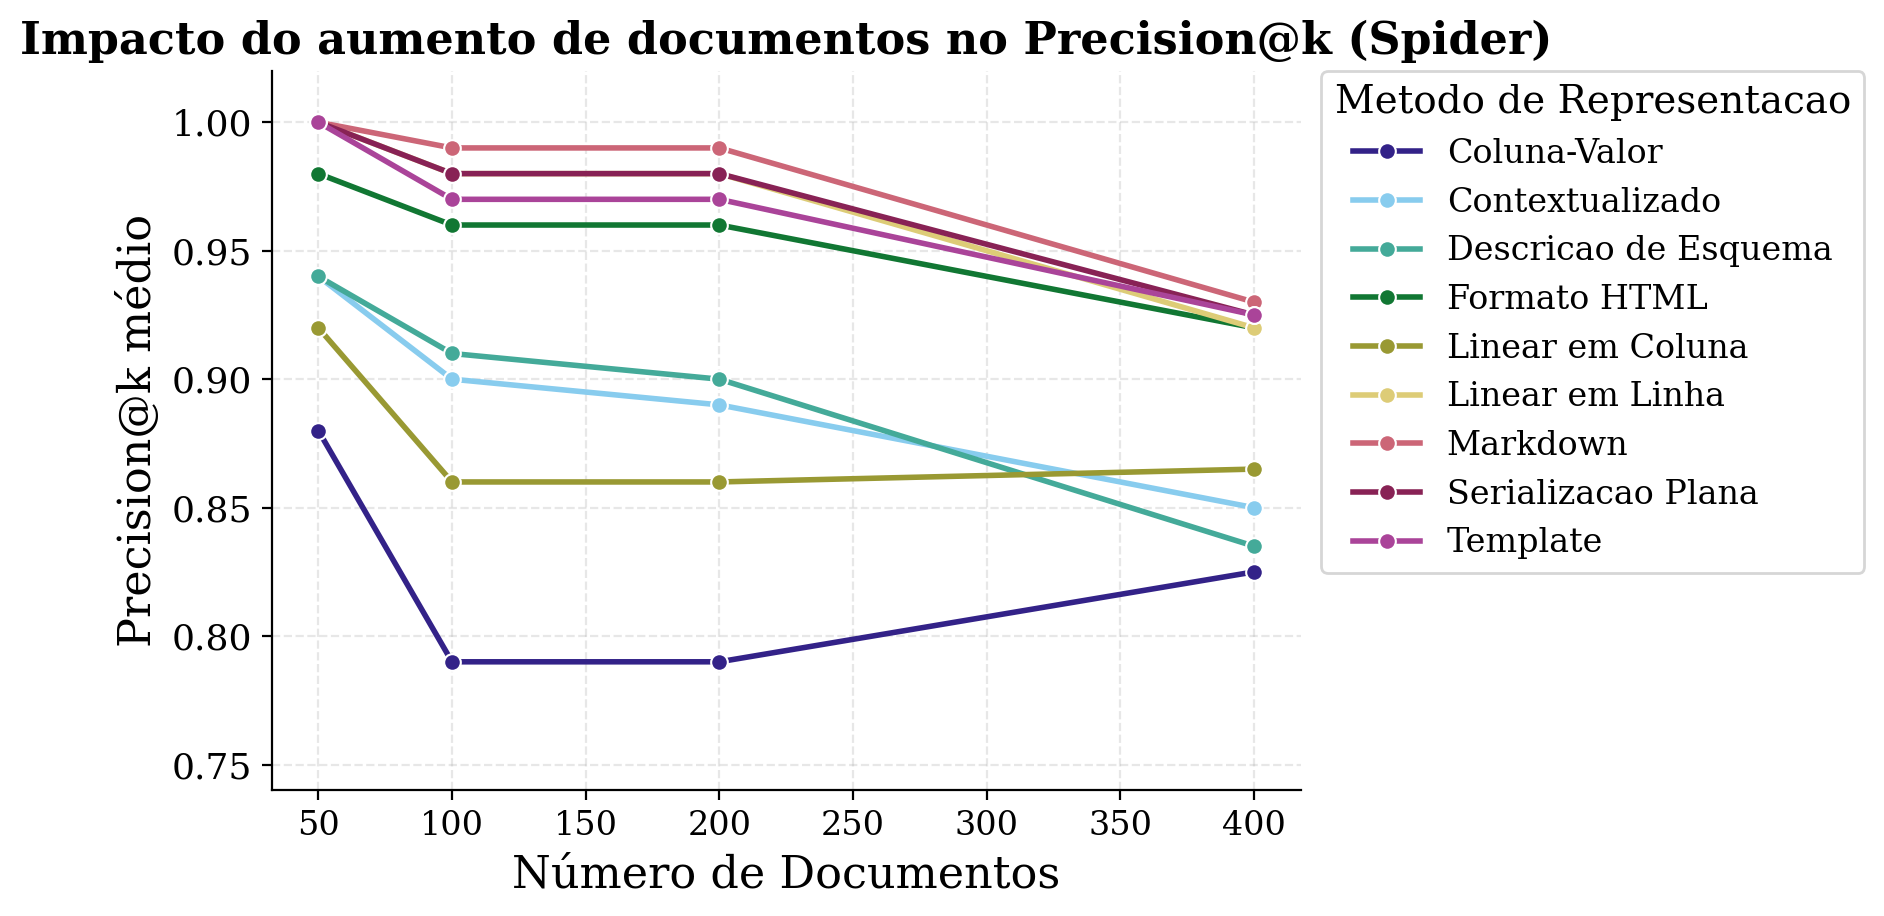

In [7]:
# Figure 2 - Impact of increasing number of documents (Spider only)
df_spider_results = datasets['spider'].copy()

# Garante a metrica Recall@k no mesmo padrao da Figura 1
df_spider_results['recall_at_k'] = extract_recall_at_k(df_spider_results['Evalution'])

# Agregacao por metodo x tamanho de corpus
df_trend = (
    df_spider_results
    .groupby(['Representation', 'Num documents'], as_index=False)['recall_at_k']
    .mean()
    .rename(columns={'recall_at_k': 'mean_recall'})
)

# Ordem fixa dos metodos para consistencia visual
df_trend['Representation'] = pd.Categorical(
    df_trend['Representation'],
    categories=METHOD_ORDER,
    ordered=True
)
df_trend = df_trend.sort_values(['Representation', 'Num documents'])

# Limites de eixo y mais informativos (mantendo leitura de variacao fina)
y_min = max(0.0, df_trend['mean_recall'].min() - 0.05)
y_max = min(1.02, df_trend['mean_recall'].max() + 0.03)

fig, ax = plt.subplots(figsize=(9.2, 4.8))

# Paleta consistente com Figura 1
method_colors = [METHOD_COLORS[m] for m in METHOD_ORDER if m in df_trend['Representation'].unique()]
sns.lineplot(
    data=df_trend,
    x='Num documents',
    y='mean_recall',
    hue='Representation',
    hue_order=[m for m in METHOD_ORDER if m in df_trend['Representation'].unique()],
    palette=method_colors,
    marker='o',
    linewidth=2.0,
    markersize=6,
    ax=ax
)

# Melhora nomes na legenda
handles, labels = ax.get_legend_handles_labels()
labels = [METHOD_NAMES.get(lbl, lbl) for lbl in labels]
ax.legend(
    handles=handles,
    labels=labels,
    title='Metodo de Representacao',
    bbox_to_anchor=(1.02, 1.0),
    loc='upper left',
    borderaxespad=0.0,
    # frameon=False
)

ax.set_title('Impacto do aumento de documentos no Precision@k (Spider)', fontweight='bold')
ax.set_xlabel('Número de Documentos')
ax.set_ylabel('Precision@k médio')
ax.set_ylim(y_min, y_max)
# ax.set_ylim(0.5, 1.00)
ax.grid(True, linestyle='--', alpha=0.30)

fig.tight_layout()

# Exportacao para paper
out_dir = Path('figures')
out_dir.mkdir(parents=True, exist_ok=True)
pdf_path2 = out_dir / 'figure2_spider_doc_impact.pdf'
png_path2 = out_dir / 'figure2_spider_doc_impact.png'
fig.savefig(pdf_path2, format='pdf', bbox_inches='tight')
fig.savefig(png_path2, dpi=600, bbox_inches='tight')

print(f'Figura salva em: {pdf_path2}')
print(f'Figura salva em: {png_path2}')
plt.show()